In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Dataset path

dataset_path = "./data"

print(os.listdir(dataset_path))

['leapGestRecog']


In [9]:
dataset_path = "./data/leapGestRecog/leapGestRecog"

print(os.listdir(dataset_path))

['00', '01', '02', '03', '04', '05', '06', '07', '08', '09']


In [10]:
sample_path = "./data/leapGestRecog/00"

print(os.listdir(sample_path))

['01_palm', '02_l', '03_fist', '04_fist_moved', '05_thumb', '06_index', '07_ok', '08_palm_moved', '09_c', '10_down']


In [11]:
import cv2
import numpy as np

data = []
labels = []

image_size = 64

gesture_classes = [
    "01_palm",
    "02_l",
    "03_fist",
    "04_fist_moved",
    "05_thumb",
    "06_index"
]

label_map = {
    "01_palm": 0,
    "02_l": 1,
    "03_fist": 2,
    "04_fist_moved": 3,
    "05_thumb": 4,
    "06_index": 5
}

# Load images

for person in os.listdir(dataset_path):

    person_path = os.path.join(dataset_path, person)

    for gesture in gesture_classes:

        gesture_path = os.path.join(person_path, gesture)

        images = os.listdir(gesture_path)[:40]

        for image_name in images:

            img_path = os.path.join(gesture_path, image_name)

            img = cv2.imread(img_path)

            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

            img = cv2.resize(img, (image_size, image_size))

            img = img / 255.0

            data.append(img.flatten())

            labels.append(label_map[gesture])

print("Images loaded successfully!")

Images loaded successfully!


In [12]:
data = np.array(data)
labels = np.array(labels)

print("Data shape:", data.shape)
print("Labels shape:", labels.shape)

Data shape: (6000, 4096)
Labels shape: (6000,)


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    data,
    labels,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (4800, 4096)
Testing data: (1200, 4096)


In [14]:
from sklearn.svm import SVC

model = SVC(kernel="rbf")

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [16]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9975


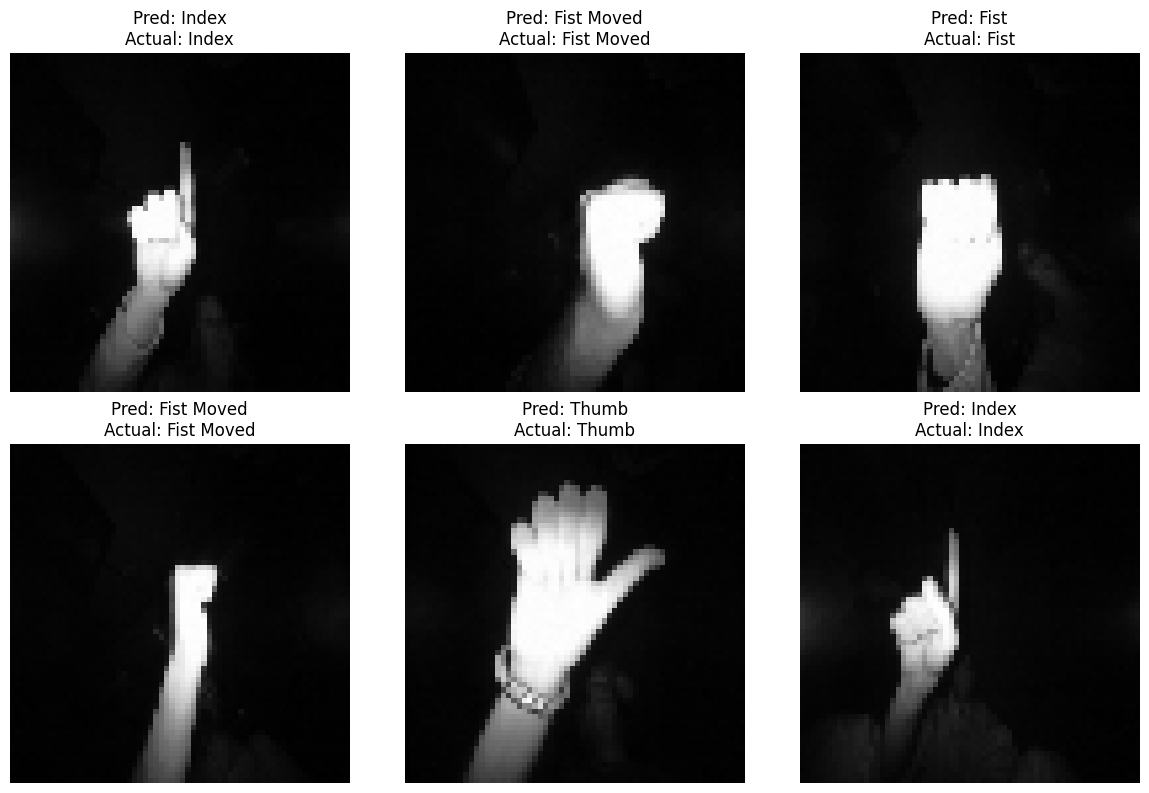

In [17]:
gesture_names = {
    0: "Palm",
    1: "L",
    2: "Fist",
    3: "Fist Moved",
    4: "Thumb",
    5: "Index"
}

plt.figure(figsize=(12,8))

for i in range(6):

    plt.subplot(2,3,i+1)

    img = X_test[i].reshape(64,64)

    plt.imshow(img, cmap="gray")

    pred = gesture_names[y_pred[i]]

    actual = gesture_names[y_test[i]]

    plt.title(f"Pred: {pred}\nActual: {actual}")

    plt.axis("off")

plt.tight_layout()
plt.show()

In [18]:
import pickle

with open("models/gesture_recognition_model.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model saved successfully!")

Model saved successfully!
